# Week 2: Lasso, Ridge, and Elastic Net Regression
**Victor Vasquez Gil**

## 1. Research Question

Can borrower and loan characteristics help predict Lending Club interest rates? Does using ridge, lasso, or elastic net improve predictions or give us a simpler model than ordinary linear regression?

My capstone focuses on credit risk. For this assignment, I am using interest rate (`int_rate`) because it is a continuous variable that fits the linear regression methods covered this week.

I compare five approaches: predicting the average interest rate, ordinary linear regression, ridge, lasso, and elastic net. I use a sample of 50,000 loans, with 80% for model development and 20% for testing. Within the development set, I use five-fold cross-validation to tune the models and compare their RMSE.

I wanted to see whether regularization would improve prediction when some of the features contain similar information, and whether fewer coefficients could produce similar results.

In [14]:
import importlib.util
import subprocess
import sys

from pathlib import Path
import sys, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import kagglehub
from IPython.display import display, HTML, Markdown
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
from threadpoolctl import threadpool_limits
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay)

In [15]:
packages = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib",
            "seaborn": "seaborn", "sklearn": "scikit-learn", "kagglehub": "kagglehub",
            "IPython": "ipython", "threadpoolctl": "threadpoolctl"}
missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])
    importlib.invalidate_caches()
print("Required packages are available.")

Required packages are available.


In [16]:
SEED = 42
SAMPLE_SIZE = 50_000
CHUNK_SIZE = 25_000
N_JOBS = 1
CV_FOLDS = 5
MAX_ITER = 20_000
thread_limit = threadpool_limits(limits=1)
DATASET_URL = "https://www.kaggle.com/datasets/wordsforthewise/lending-club"
DATASET_VERSION = 3
DATASET_HANDLE = "wordsforthewise/lending-club"
SOURCE_FILE = "accepted_2007_to_2018Q4.csv.gz"
numeric_candidates = ["loan_amnt", "annual_inc", "dti", "fico_range_low", "open_acc",
    "pub_rec", "revol_bal", "revol_util", "total_acc", "delinq_2yrs", "inq_last_6mths"]
categorical_candidates = ["term", "home_ownership", "purpose", "emp_length"]
INK, MUTED, TEAL, ORANGE, BLUE = "#172B4D", "#596579", "#137C8B", "#B85C20", "#315F91"
COLORS = ["#9AA6B2", BLUE, TEAL, ORANGE, "#8064A2"]
sns.set_theme(style="whitegrid", context="notebook", rc={
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#E5EAF0",
    "grid.color": "#E5EAF0", "axes.labelcolor": MUTED, "text.color": INK,
    "font.family": "DejaVu Sans", "figure.dpi": 130,
})

def finish_figure(fig, name):
    fig.savefig(OUTPUT_DIR / (name + ".png"), dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()

def show_table(frame, decimals=3):
    fmts = {c: (lambda v: f"{v:,.{decimals}f}") for c in frame.select_dtypes(include="floating").columns}
    fmts.update({c: (lambda v: f"{v:,d}") for c in frame.select_dtypes(include="integer").columns})
    html = frame.to_html(index=False, border=0, classes="lc-table", formatters=fmts)
    display(HTML("""<style>
    .lc-table {width:100%;border-collapse:collapse;font-family:system-ui;color:#172B4D;background:white;}
    .lc-table th {background:#172B4D;color:white;padding:11px;text-align:right;}
    .lc-table td {padding:10px;border-bottom:1px solid #E5EAF0;text-align:right;}
    .lc-table tr:nth-child(even) {background:#F4F7FA;}
    .lc-table td:first-child,.lc-table th:first-child {text-align:left;}
    </style>""" + html))

def clean_number(series):
    text = series.astype("string").str.strip().str.replace(",", "", regex=False).str.replace("%", "", regex=False)
    return pd.to_numeric(text, errors="coerce").astype(float).replace([np.inf, -np.inf], np.nan)

def make_preprocessor():
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median", keep_empty_features=True), numeric_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value="Missing", keep_empty_features=True)),
            ("encode", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
        ]), categorical_cols),
    ], remainder="drop", verbose_feature_names_out=True)

def make_pipeline(model, scaled=True):
    return Pipeline([("prepare", make_preprocessor()),
                     ("scale", StandardScaler() if scaled else "passthrough"),
                     ("model", model)])

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")

OUTPUT_DIR = Path("week2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Python 3.14.2 | pandas 3.0.6 | scikit-learn 1.9.1


## 2. Data and Sampling

The data comes from version 3 of the Lending Club dataset on Kaggle. Since the file is large, the code reads 25,000 rows at a time and keeps a random sample of 50,000 eligible loans. I use a random seed of 42 so the sample can be reproduced.

I include loans with interest rates greater than 0 and less than 100 percent. I do not filter by repayment status because the question here is about interest rates.

The predictors include income, loan amount, debt-to-income ratio, FICO, credit history, and several categorical features. I leave out grade, subgrade, and installment because they can reveal information about the pricing decision.

This dataset only contains accepted loans, so the findings do not describe people whose applications were rejected.

In [17]:
DATA_PATH = Path(kagglehub.dataset_download(
    f"{DATASET_HANDLE}/versions/{DATASET_VERSION}", path=SOURCE_FILE
))
requested = ["id", "issue_d", "loan_status", "int_rate"] + numeric_candidates + categorical_candidates
header = pd.read_csv(DATA_PATH, nrows=0)
required = numeric_candidates + categorical_candidates + ["int_rate"]
absent = sorted(set(required) - set(header.columns))
if absent:
    raise ValueError(f"Required columns missing: {absent}")
available = [c for c in requested if c in header.columns]
text_columns = [c for c in ["id", "issue_d", "loan_status"] + categorical_candidates if c in available]
rng = np.random.default_rng(SEED)
sample_buffer = None
rows_scanned = eligible_count = 0
with pd.read_csv(DATA_PATH, usecols=available, chunksize=CHUNK_SIZE,
                 low_memory=False, dtype={c: "string" for c in text_columns}) as reader:
    for batch, chunk in enumerate(reader, start=1):
        chunk["source_row"] = np.arange(rows_scanned, rows_scanned + len(chunk))
        rows_scanned += len(chunk)
        chunk["int_rate"] = clean_number(chunk["int_rate"])
        eligible = chunk["int_rate"].gt(0) & chunk["int_rate"].lt(100)
        chunk = chunk.loc[eligible].copy()
        eligible_count += len(chunk)
        if not chunk.empty:
            chunk["_random_priority"] = rng.random(len(chunk))
            sample_buffer = chunk if sample_buffer is None else pd.concat([sample_buffer, chunk], ignore_index=True)
            sample_buffer = sample_buffer.nsmallest(SAMPLE_SIZE, "_random_priority")
        if batch % 20 == 0:
            print(f"Scanned {rows_scanned:,} source rows…")
if sample_buffer is None or sample_buffer.empty:
    raise ValueError("No eligible rows found.")
loans = sample_buffer.drop(columns="_random_priority").reset_index(drop=True)
del sample_buffer
if "id" in loans and loans["id"].notna().any():
    ids = loans["id"].dropna()
    if ids.duplicated().any():
        raise ValueError("Duplicate loan IDs found; reconcile before splitting.")
else:
    print("No usable loan IDs: repeated-loan or repeated-borrower checks remain limited.")
sampling_summary = pd.DataFrame({
    "Stage": ["Source rows scanned", "Eligible loans", "Sample retained"],
    "Rows": [rows_scanned, eligible_count, len(loans)],
})
show_table(sampling_summary)

Scanned 500,000 source rows…
Scanned 1,000,000 source rows…
Scanned 1,500,000 source rows…
Scanned 2,000,000 source rows…


Stage,Rows
Source rows scanned,"2,260,701"
Eligible loans,"2,260,668"
Sample retained,"50,000"


In [18]:
numeric_cols = numeric_candidates.copy()
categorical_cols = categorical_candidates.copy()
X = loans[numeric_cols + categorical_cols].copy()
for c in numeric_cols:
    X[c] = clean_number(X[c])
for c in categorical_cols:
    values = X[c].astype("string").str.strip().replace("", pd.NA)
    X[c] = values.astype(object).where(values.notna(), np.nan)
y = loans["int_rate"].astype(float).rename("interest_rate")
if not X.index.equals(y.index):
    raise ValueError("Predictor and target indices are misaligned.")
print(f"Ready: {len(X):,} loans × {X.shape[1]} original predictors")

Ready: 50,000 loans × 15 original predictors


## 3. Splitting the Data

I set aside 10,000 loans for testing and use the remaining 40,000 for EDA, training, and cross validation.

The test set stays separate until model selection is finished. This gives me a way to check how the selected model performs on loans it was not trained on.

Because the split is random, it does not show how well the model would predict loans from a later time period. That would require a chronological split.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
cv_splits = list(cv.split(X_train, y_train))
manifest = pd.DataFrame({"source_row": loans["source_row"], "split": "development"})
manifest.loc[X_test.index, "split"] = "test"
if "id" in loans:
    manifest["loan_id"] = loans["id"]
manifest.to_csv(OUTPUT_DIR / "split_manifest.csv", index=False)
show_table(pd.DataFrame({"Split": ["Development / CV", "Test"], "Loans": [len(y_train), len(y_test)]}))

Split,Loans
Development / CV,"40,000"
Test,"10,000"


## 4. Exploring the Data

I look at missing values, the distribution of interest rates, FICO scores, and correlations between numeric predictors.

These checks help guide the preprocessing. I use training medians to fill missing numeric values and a separate label for missing categories. I also scale the predictors because values such as income and credit account counts have very different ranges.

All preprocessing is fitted within each training fold. This keeps information from the validation fold out of the training process.

Feature,Missing (%)
emp_length,6.43
revol_util,0.09
dti,0.07
fico_range_low,0.00
open_acc,0.00
loan_amnt,0.00
annual_inc,0.00
revol_bal,0.00


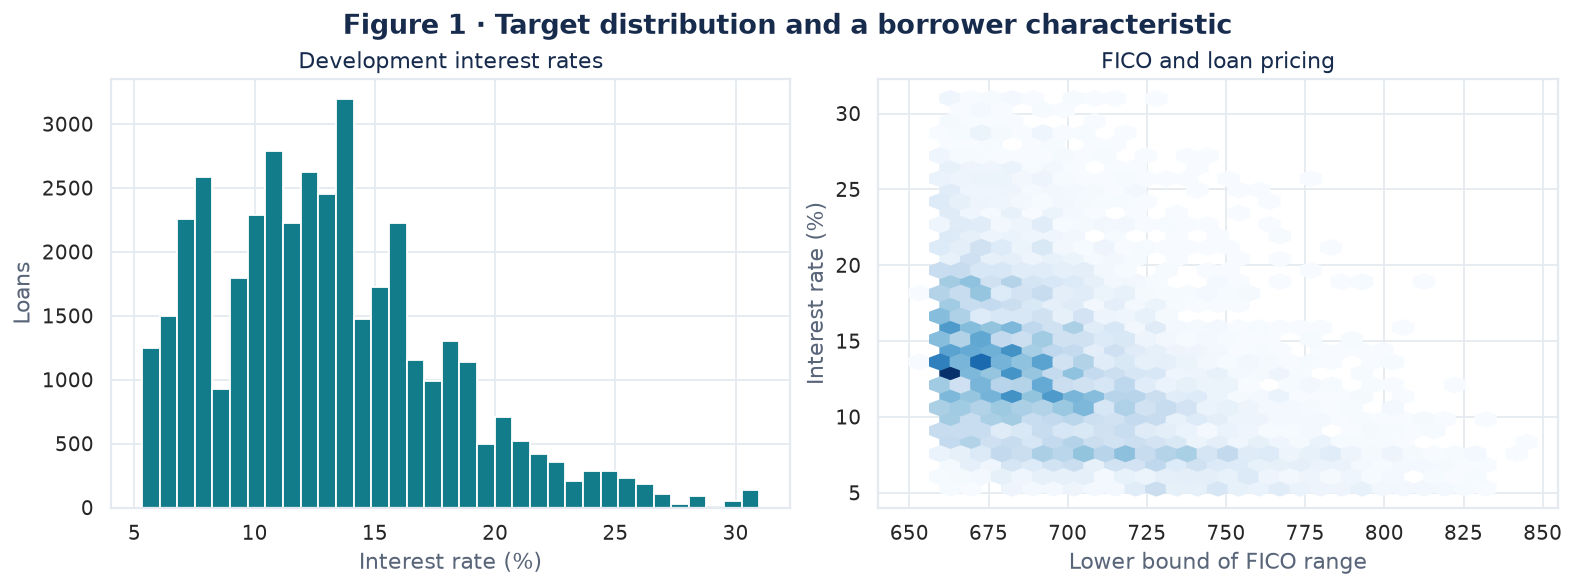

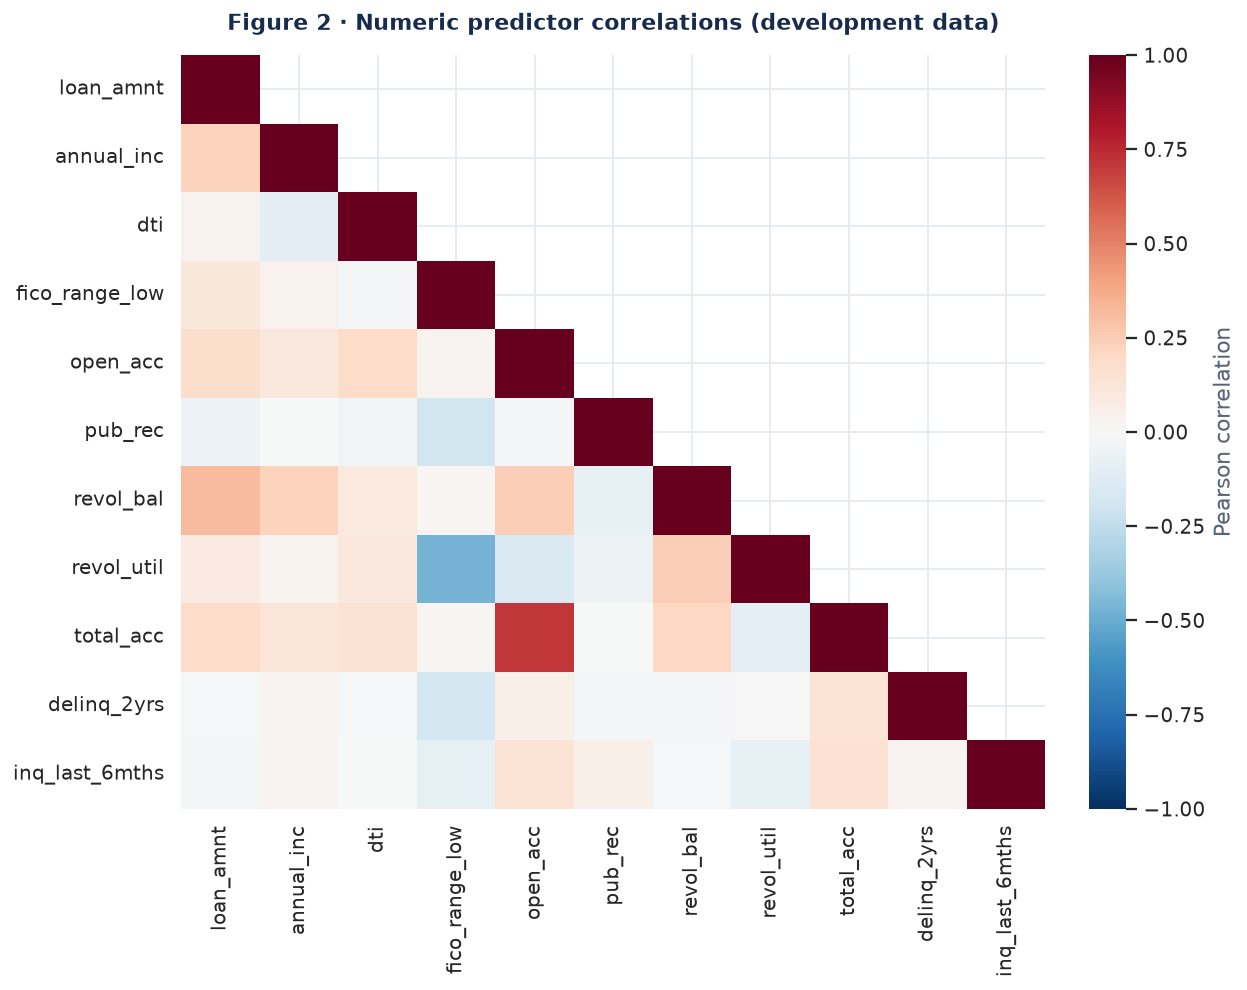

Feature 1,Feature 2,Correlation,Absolute correlation
open_acc,total_acc,0.719,0.719
fico_range_low,revol_util,-0.474,0.474
loan_amnt,revol_bal,0.320,0.320
revol_bal,revol_util,0.250,0.250
open_acc,revol_bal,0.243,0.243


In [20]:
missing_table = (X_train.isna().mean().mul(100).rename("Missing (%)").rename_axis("Feature")
                 .reset_index().sort_values("Missing (%)", ascending=False))
show_table(missing_table.head(8), 2)
missing_table.to_csv(OUTPUT_DIR / "training_missingness.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), layout="constrained")
axes[0].hist(y_train, bins=35, color=TEAL, edgecolor="white")
axes[0].set(title="Development interest rates", xlabel="Interest rate (%)", ylabel="Loans")
plot_rows = X_train.sample(n=min(8000, len(X_train)), random_state=SEED).index
axes[1].hexbin(X_train.loc[plot_rows, "fico_range_low"], y_train.loc[plot_rows],
               gridsize=30, mincnt=1, cmap="Blues")
axes[1].set(title="FICO and loan pricing", xlabel="Lower bound of FICO range", ylabel="Interest rate (%)")
fig.suptitle("Figure 1 · Target distribution and a borrower characteristic", fontsize=15, fontweight="bold")
finish_figure(fig, "figure_1_target_eda")
corr = X_train[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(9.5, 7.5), layout="constrained")
sns.heatmap(corr, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            mask=np.triu(np.ones_like(corr, dtype=bool), k=1), cbar_kws={"label": "Pearson correlation"})
ax.set_title("Figure 2 · Numeric predictor correlations (development data)", pad=14, fontweight="bold")
finish_figure(fig, "figure_2_correlations")
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().rename("Correlation").reset_index()
pairs.columns = ["Feature 1", "Feature 2", "Correlation"]
pairs["Absolute correlation"] = pairs["Correlation"].abs()
pairs = pairs.sort_values("Absolute correlation", ascending=False)
show_table(pairs.head(5), 3)

## 5. Models and Tuning

The models use the same preprocessing, but handle coefficients differently:

- **Ordinary linear regression:** fits the data without a coefficient penalty.
- **Ridge:** shrinks coefficients using a penalty based on their squared values.
- **Lasso:** can shrink some coefficients to zero.
- **Elastic net:** combines ridge and lasso penalties.

I've test different `alpha` values to control regularization strength. For elastic net, I also test `l1_ratio` values of 0.1, 0.5, and 0.9. Values closer to 1 put more weight on the lasso penalty.

I've also use cross-validation RMSE to select the model. RMSE and MAE are measured in interest-rate percentage points, with lower values indicating smaller errors. I also report R^2.

Cross-validation, regularization, and keeping the test set separate help reduce overfitting. They do not guarantee that a model will perform equally well on future data.

In [21]:
scoring = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}
fitted, searches, cv_rows = {}, {}, []
convergence_warnings = {}
baseline_specs = {"Mean baseline": DummyRegressor(strategy="mean"), "OLS": LinearRegression()}
for name, estimator in baseline_specs.items():
    start = time.perf_counter()
    pipeline = make_pipeline(estimator)
    scores = cross_validate(pipeline, X_train, y_train, cv=cv_splits, scoring=scoring,
                            return_train_score=True, n_jobs=N_JOBS, error_score="raise")
    fitted[name] = pipeline.fit(X_train, y_train)
    cv_rows.append({"Model": name, "CV RMSE": -scores["test_rmse"].mean(),
                    "CV SD": scores["test_rmse"].std(ddof=0),
                    "CV MAE": -scores["test_mae"].mean(), "CV R2": scores["test_r2"].mean(),
                    "CV train RMSE": -scores["train_rmse"].mean(), "Best parameters": "None"})
    print(f"{name} completed in {time.perf_counter()-start:.1f}s")

ridge_grid = np.logspace(-3, 5, 9)
sparse_grid = np.logspace(-4, 0, 7)
specs = {
    "Ridge": (Ridge(solver="lsqr", tol=1e-6), {"model__alpha": ridge_grid}),
    "Lasso": (Lasso(max_iter=MAX_ITER, tol=1e-4, random_state=SEED), {"model__alpha": sparse_grid}),
    "Elastic Net": (ElasticNet(max_iter=MAX_ITER, tol=1e-4, random_state=SEED),
                    {"model__alpha": sparse_grid, "model__l1_ratio": [0.1, 0.5, 0.9]}),
}
for name, (estimator, grid) in specs.items():
    print("Tuning", name, flush=True)
    search = GridSearchCV(make_pipeline(estimator), grid, cv=cv_splits, scoring=scoring,
                          refit="rmse", n_jobs=N_JOBS, return_train_score=True, error_score="raise")
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        search.fit(X_train, y_train)
    convergence_warnings[name] = sum(issubclass(w.category, ConvergenceWarning) for w in caught)
    other_warnings = [str(w.message) for w in caught if not issubclass(w.category, ConvergenceWarning)]
    if other_warnings:
        print("Preprocessing warnings:", sorted(set(other_warnings)))
    searches[name], fitted[name] = search, search.best_estimator_
    results, i = search.cv_results_, search.best_index_
    cv_rows.append({"Model": name, "CV RMSE": -results["mean_test_rmse"][i],
                    "CV SD": results["std_test_rmse"][i], "CV MAE": -results["mean_test_mae"][i],
                    "CV R2": results["mean_test_r2"][i], "CV train RMSE": -results["mean_train_rmse"][i],
                    "Best parameters": str(search.best_params_)})
    pd.DataFrame(results).to_csv(OUTPUT_DIR / (name.lower().replace(" ", "_") + "_cv_results.csv"), index=False)
cv_results = pd.DataFrame(cv_rows)
selected_name = cv_results.loc[cv_results["Model"].ne("Mean baseline")].sort_values("CV RMSE").iloc[0]["Model"]
print("Model selected using CV only:", selected_name)
print("Convergence-warning counts:", convergence_warnings)
show_table(cv_results, 4)
cv_results.to_csv(OUTPUT_DIR / "cv_model_comparison.csv", index=False)

Mean baseline completed in 1.1s
OLS completed in 1.5s
Tuning Ridge
Tuning Lasso
Tuning Elastic Net
Model selected using CV only: Elastic Net
Convergence-warning counts: {'Ridge': 0, 'Lasso': 0, 'Elastic Net': 0}


Model,CV RMSE,CV SD,CV MAE,CV R2,CV train RMSE,Best parameters
Mean baseline,4.8358,0.0484,3.8108,-0.0001,4.8359,None
OLS,3.7221,0.0349,2.8413,0.4075,3.7141,None
Ridge,3.7220,0.0349,2.8413,0.4075,3.7142,{'model__alpha': np.float64(100.0)}
Lasso,3.7218,0.0352,2.8411,0.4076,3.7147,{'model__alpha': np.float64(0.01)}
Elastic Net,3.7217,0.0352,2.8411,0.4076,3.7146,"{'model__alpha': np.float64(0.01), 'model__l1_ratio': 0.9}"


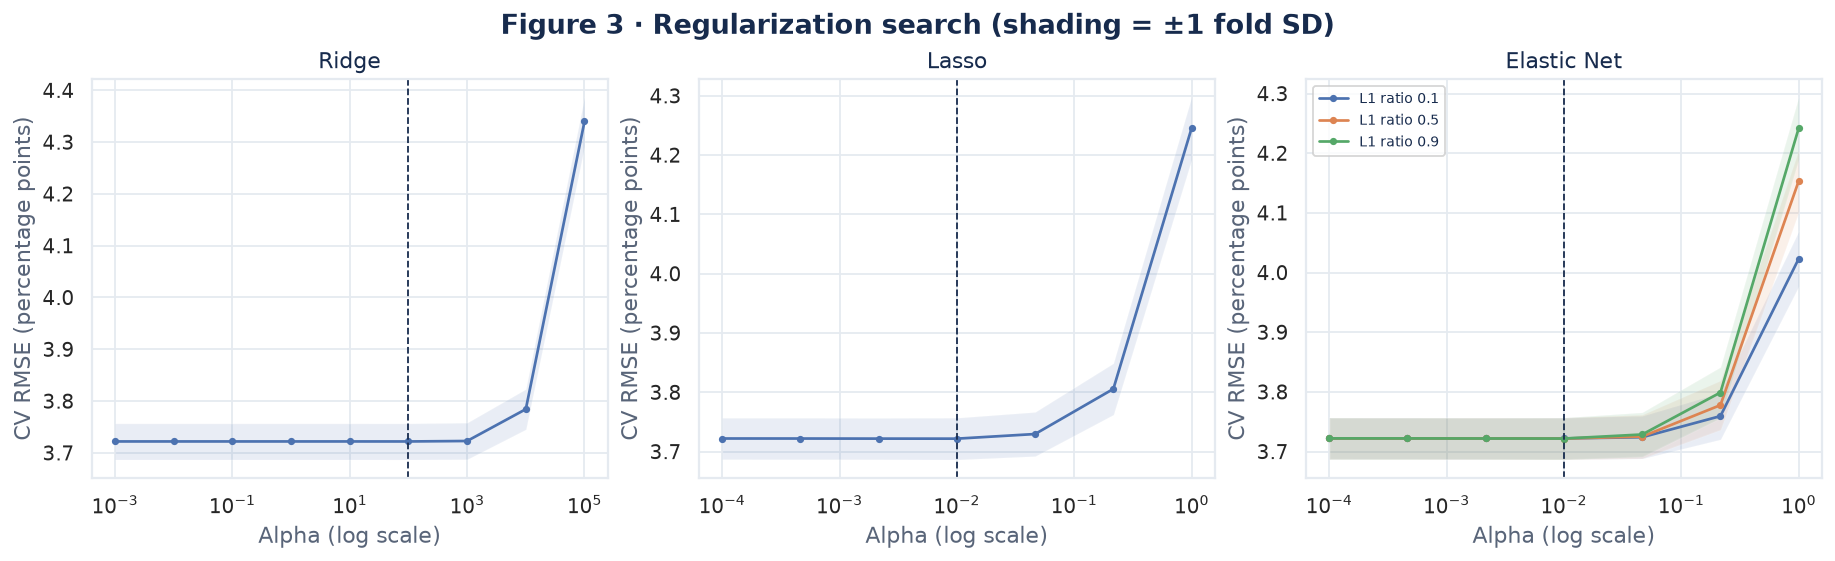

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), layout="constrained")
for ax, name in zip(axes, ["Ridge", "Lasso", "Elastic Net"]):
    values = pd.DataFrame(searches[name].cv_results_)
    groups = values.groupby("param_model__l1_ratio") if name == "Elastic Net" else [(None, values)]
    for ratio, group in groups:
        group = group.sort_values("param_model__alpha")
        a = group["param_model__alpha"].astype(float).to_numpy()
        mean = -group["mean_test_rmse"].to_numpy()
        sd = group["std_test_rmse"].to_numpy()
        ax.plot(a, mean, marker="o", ms=3, label=f"L1 ratio {ratio}" if ratio is not None else name)
        ax.fill_between(a, mean-sd, mean+sd, alpha=0.12)
    ax.axvline(searches[name].best_params_["model__alpha"], color=INK, ls="--", lw=1)
    ax.set(xscale="log", title=name, xlabel="Alpha (log scale)", ylabel="CV RMSE (percentage points)")
    if name == "Elastic Net": ax.legend(fontsize=8)
fig.suptitle("Figure 3 · Regularization search (shading = ±1 fold SD)", fontweight="bold", fontsize=15)
finish_figure(fig, "figure_3_regularization_search")

## 6. Comparing the Results

After selecting the model through cross-validation, I compare all five approaches on the test set.

I also include training error to see how much performance changes on unseen loans. I do not change the selected model based on which one happens to have the lowest test error.

Model,Training RMSE,Test RMSE,Test MAE,Test R2,Nonzero coefficients,CV RMSE,CV SD,CV selected
Mean baseline,4.8359,4.8988,3.8346,-0.0001,0,4.8358,0.0484,False
OLS,3.7149,3.8022,2.8615,0.3976,40,3.7221,0.0349,False
Ridge,3.7150,3.8020,2.8614,0.3976,40,3.7220,0.0349,False
Lasso,3.7155,3.8008,2.8619,0.3980,31,3.7218,0.0352,False
Elastic Net,3.7154,3.8009,2.8618,0.3980,32,3.7217,0.0352,True


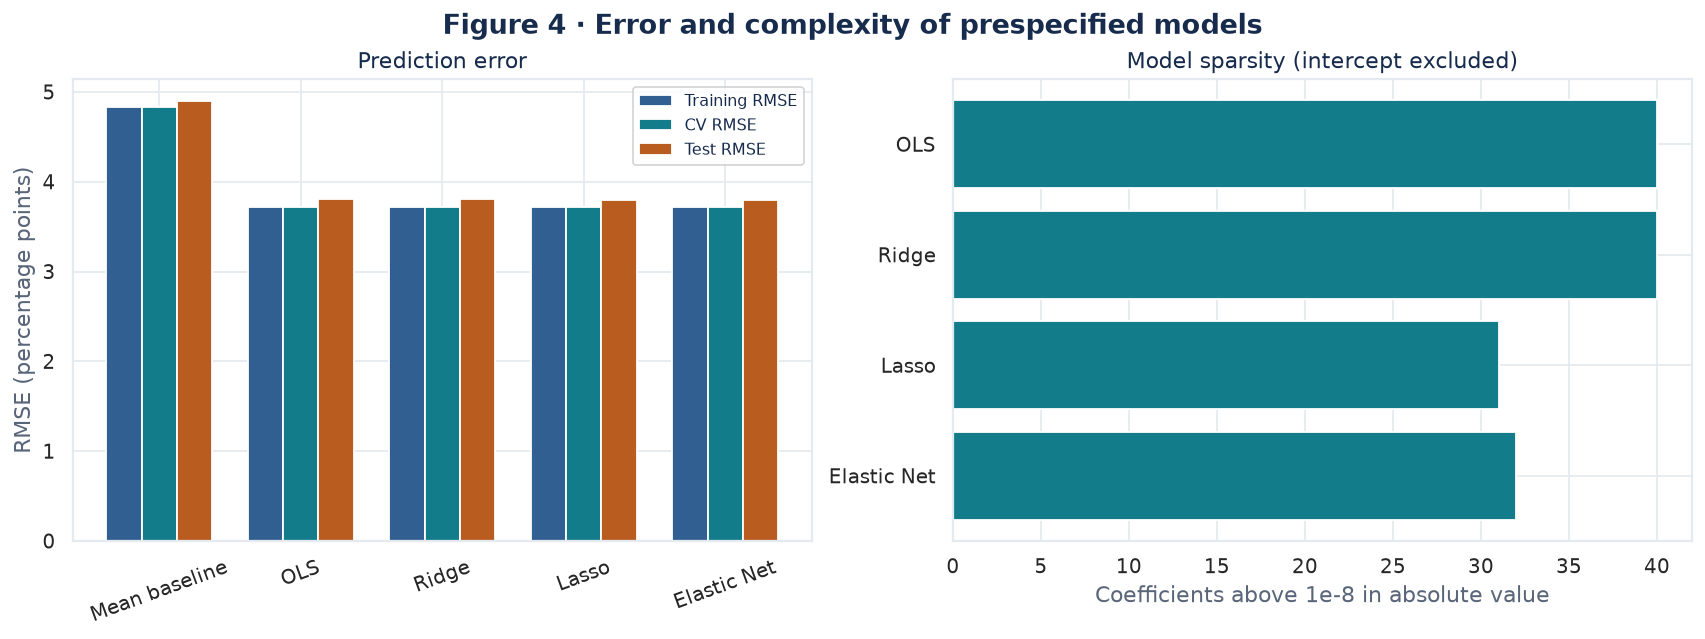

In [23]:
metric_rows, predictions = [], {}
for name, model in fitted.items():
    train_pred, test_pred = model.predict(X_train), model.predict(X_test)
    predictions[name] = test_pred
    coef = getattr(model.named_steps["model"], "coef_", None)
    metric_rows.append({"Model": name,
        "Training RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "Test MAE": mean_absolute_error(y_test, test_pred), "Test R2": r2_score(y_test, test_pred),
        "Nonzero coefficients": int(np.count_nonzero(np.abs(coef) > 1e-8)) if coef is not None else 0})
results = pd.DataFrame(metric_rows).merge(cv_results[["Model", "CV RMSE", "CV SD"]], on="Model")
results["CV selected"] = results["Model"].eq(selected_name)
show_table(results, 4)
results.to_csv(OUTPUT_DIR / "final_model_comparison.csv", index=False)
pd.DataFrame({"source_row": loans.loc[X_test.index, "source_row"].to_numpy(),
              "observed_interest_rate": y_test.to_numpy(), **predictions}).to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), layout="constrained")
pos = np.arange(len(results)); width = 0.25
for offset, column, color in [(-width, "Training RMSE", BLUE), (0, "CV RMSE", TEAL), (width, "Test RMSE", ORANGE)]:
    axes[0].bar(pos+offset, results[column], width=width, label=column, color=color)
axes[0].set_xticks(pos, results["Model"], rotation=20)
axes[0].set_ylabel("RMSE (percentage points)")
axes[0].set_title("Prediction error")
axes[0].legend(fontsize=9)
coeff_only = results[results["Model"].ne("Mean baseline")]
axes[1].barh(coeff_only["Model"], coeff_only["Nonzero coefficients"], color=TEAL)
axes[1].set(xlabel="Coefficients above 1e-8 in absolute value", title="Model sparsity (intercept excluded)")
axes[1].invert_yaxis()
fig.suptitle("Figure 4 · Error and complexity of prespecified models", fontsize=15, fontweight="bold")
finish_figure(fig, "figure_4_model_comparison")

## 7. Coefficients and Prediction Errors

The coefficient plots show how increasing the penalty changes the model. Each panel tracks the five largest absolute OLS coefficients to keep the figure readable.

I also compare predicted and actual interest rates and examine the residuals. These plots help show where the model makes larger errors.

The coefficients describe relationships within the model. They do not show that changing a borrower characteristic would cause an interest rate to change.


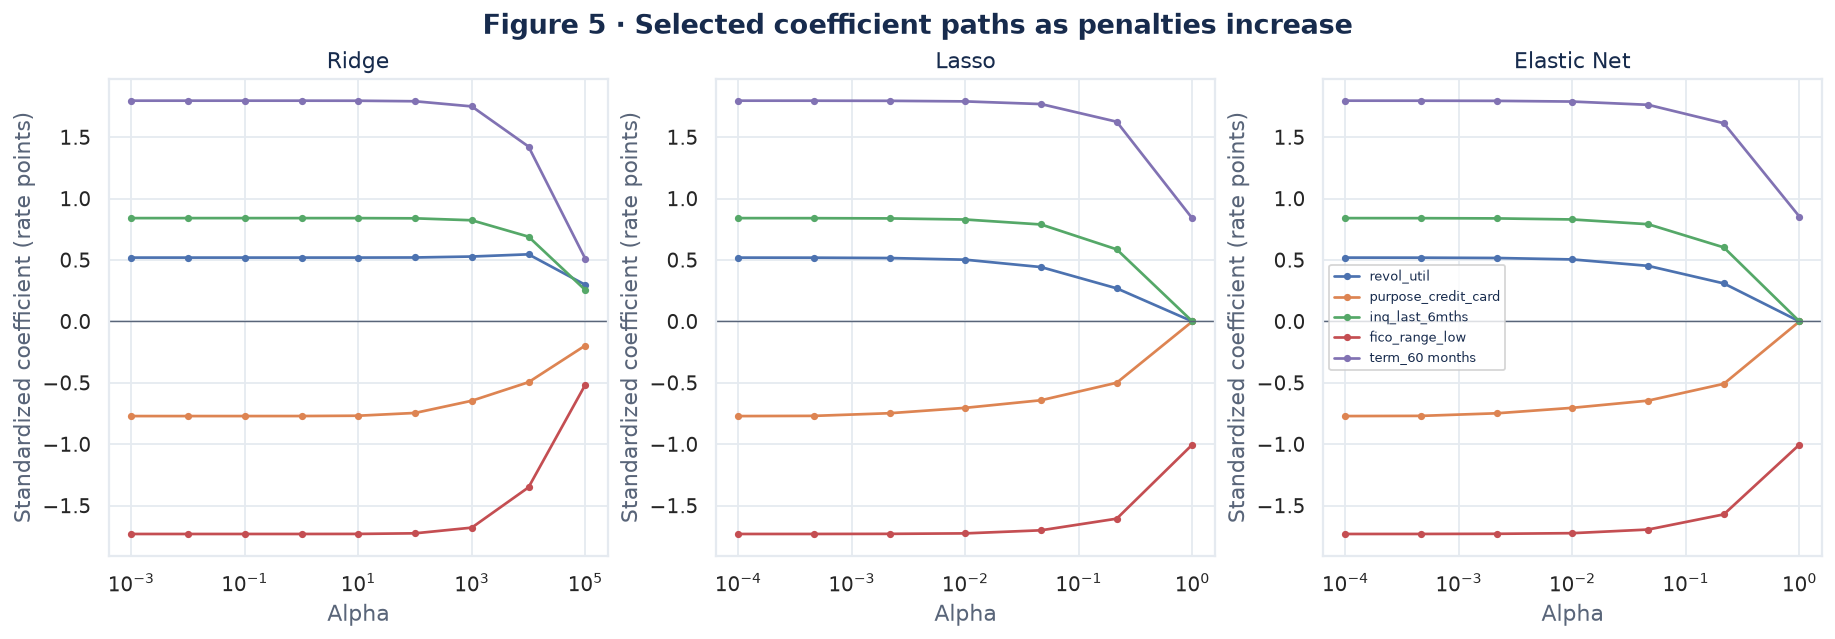

Feature,Coefficient,Absolute coefficient
cat__term_60 months,1.7901,1.7901
num__fico_range_low,-1.7242,1.7242
num__inq_last_6mths,0.8301,0.8301
cat__purpose_credit_card,-0.7036,0.7036
num__revol_util,0.5047,0.5047
num__dti,0.4734,0.4734
num__total_acc,-0.4585,0.4585
cat__purpose_other,0.3344,0.3344
num__revol_bal,-0.2996,0.2996
cat__home_ownership_MORTGAGE,-0.2960,0.2960


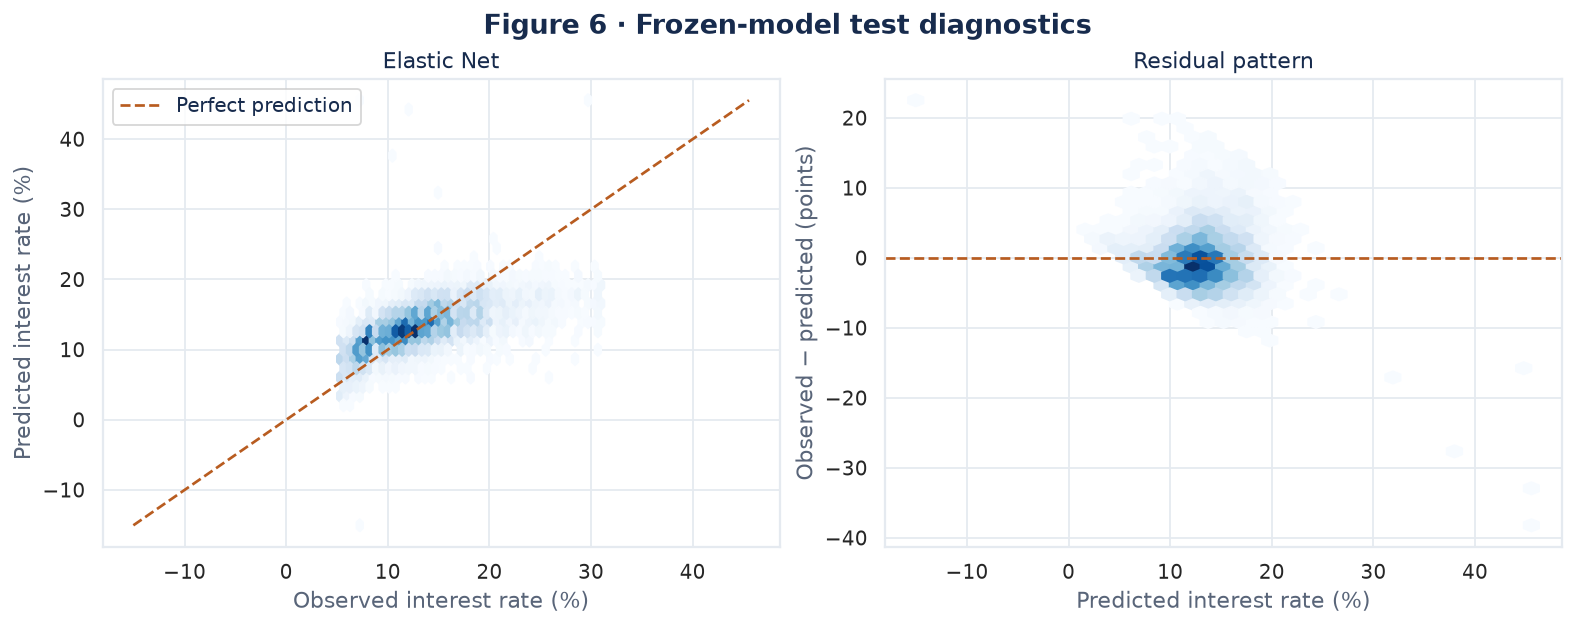

In [25]:
feature_names = fitted["OLS"].named_steps["prepare"].get_feature_names_out()
encoded = fitted["OLS"].named_steps["prepare"].transform(X_train)
encoded = fitted["OLS"].named_steps["scale"].transform(encoded)
top_indices = np.argsort(np.abs(fitted["OLS"].named_steps["model"].coef_))[-5:]
path_specs = [
    ("Ridge", Ridge(solver="lsqr", tol=1e-6), ridge_grid),
    ("Lasso", Lasso(max_iter=MAX_ITER, tol=1e-4), sparse_grid),
    ("Elastic Net", ElasticNet(l1_ratio=searches["Elastic Net"].best_params_["model__l1_ratio"],
                               max_iter=MAX_ITER, tol=1e-4), sparse_grid),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), layout="constrained")
for ax, (name, model, grid) in zip(axes, path_specs):
    coefficients = []
    for alpha in grid:
        estimator = clone(model).set_params(alpha=alpha).fit(encoded, y_train)
        coefficients.append(estimator.coef_)
    coefficients = np.asarray(coefficients)
    for j in top_indices:
        label = feature_names[j].replace("num__", "").replace("cat__", "")
        ax.plot(grid, coefficients[:,j], marker="o", ms=3, label=label)
    ax.axhline(0, color=MUTED, lw=0.8)
    ax.set(xscale="log", title=name, xlabel="Alpha", ylabel="Standardized coefficient (rate points)")
axes[-1].legend(loc="best", fontsize=7)
fig.suptitle("Figure 5 · Selected coefficient paths as penalties increase", fontsize=15, fontweight="bold")
finish_figure(fig, "figure_5_coefficient_paths")
winner = fitted[selected_name]
coef_table = pd.DataFrame({"Feature": winner.named_steps["prepare"].get_feature_names_out(),
                           "Coefficient": winner.named_steps["model"].coef_})
coef_table["Absolute coefficient"] = coef_table["Coefficient"].abs()
coef_table = coef_table.sort_values("Absolute coefficient", ascending=False)
coef_table.to_csv(OUTPUT_DIR / "selected_model_coefficients.csv", index=False)
show_table(coef_table.head(10), 4)
pred = predictions[selected_name]
residual = y_test.to_numpy() - pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), layout="constrained")
axes[0].hexbin(y_test, pred, gridsize=40, mincnt=1, cmap="Blues")
low, high = min(y_test.min(), pred.min()), max(y_test.max(), pred.max())
axes[0].plot([low,high], [low,high], color=ORANGE, ls="--", label="Perfect prediction")
axes[0].set(xlabel="Observed interest rate (%)", ylabel="Predicted interest rate (%)", title=selected_name)
axes[0].legend()
axes[1].hexbin(pred, residual, gridsize=40, mincnt=1, cmap="Blues")
axes[1].axhline(0, color=ORANGE, ls="--")
axes[1].set(xlabel="Predicted interest rate (%)", ylabel="Observed − predicted (points)", title="Residual pattern")
fig.suptitle("Figure 6 · Frozen-model test diagnostics", fontsize=15, fontweight="bold")
finish_figure(fig, "figure_6_test_diagnostics")

## 8. What I Learned

Elastic net had the lowest cross-validation RMSE, but the improvement over ordinary linear regression was only about **0.00031 percentage points**. That difference is too small for me to describe it as a meaningful improvement based on this comparison alone.

On the test set, elastic net had an **RMSE of 3.801 percentage points**, an **MAE of 2.862 points**, and an **R² of 0.398**. Its RMSE was about **22.41% lower** than the mean-prediction baseline. The borrower and loan features helped, but the model still left a substantial amount of variation unexplained.

The more useful result was the reduction in coefficients. OLS and ridge retained **40**, while lasso retained **31** and elastic net retained **32**. Lasso and elastic net had almost identical test errors. For this dataset, regularization helped simplify the model more than it improved prediction.

The correlation between `open_acc` and `total_acc` was **0.719**, which supported trying methods that handle overlapping information. I expected regularization might make a larger difference in prediction error, but that was not what the results showed.

Elastic net's training RMSE was **3.715**, compared with **3.722 in cross-validation** and **3.801 on the test set**. These values were fairly close, so I did not see a large training-to-test gap in this run.

My next step would be to test on later loan vintages and explore a small number of polynomial or interaction terms using development data. The FRED and banking datasets planned for the broader capstone have not been added to this analysis.